     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 6.6 MB/s eta 0:00:00
Generating data with 10.0% contamination...

--- Evaluation Metrics ---
On Training Data:
KNN ROC:0.9952, precision @ rank n:0.95

On Test Data:
KNN ROC:0.9644, precision @ rank n:0.9

Visualizing Results...


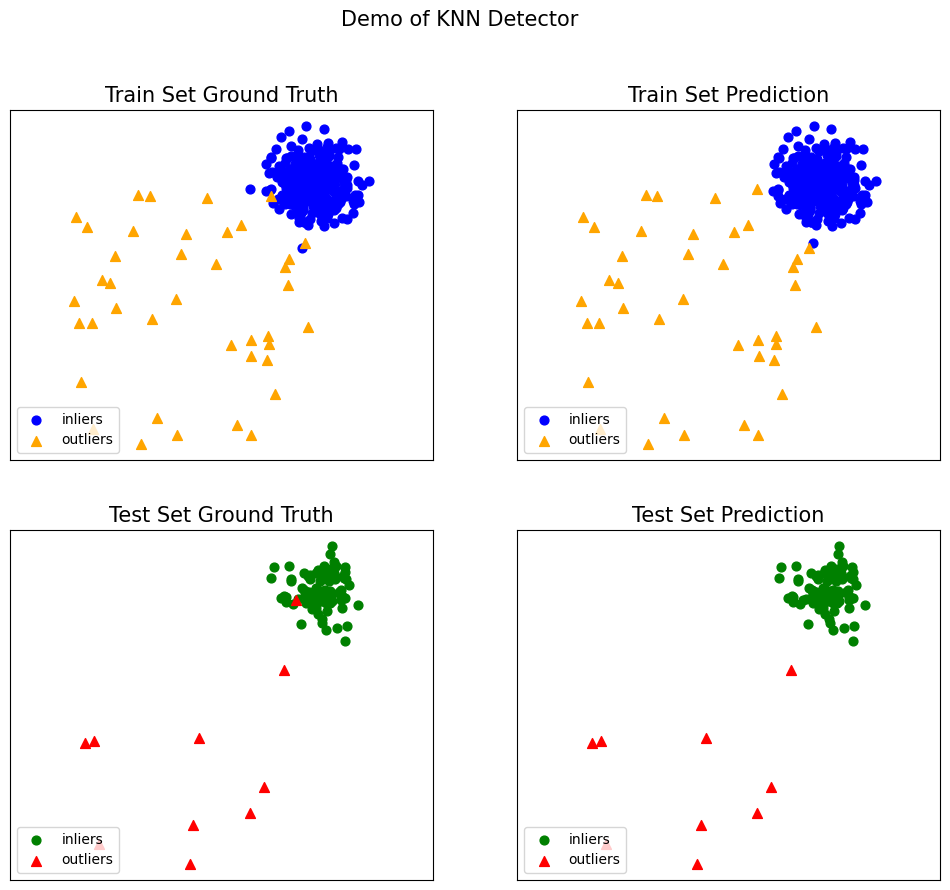

In [1]:


!pip install pyod --quiet

import numpy as np
import matplotlib.pyplot as plt
from pyod.models.knn import KNN
from pyod.utils.data import generate_data
from pyod.utils.data import evaluate_print
from pyod.utils.example import visualize

# --- 1. Data Generation ---
contamination = 0.1  # percentage of outliers
n_train = 400
n_test = 100

print(f"Generating data with {contamination*100}% contamination...")
X_train, X_test, y_train, y_test = generate_data(
    n_train=n_train, n_test=n_test,
    n_features=2, contamination=contamination, random_state=42
)

# --- 2. Model Training ---
# KNN is a robust method for anomaly detection (distance to kth neighbor)
clf_name = 'KNN'
clf = KNN(contamination=contamination)
clf.fit(X_train)

# Get the prediction labels and outlier scores
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)
y_train_scores = clf.decision_scores_  # raw outlier scores

y_test_pred = clf.predict(X_test)
y_test_scores = clf.decision_function(X_test)

# --- 3. Evaluation ---
print("\n--- Evaluation Metrics ---")
print("On Training Data:")
evaluate_print(clf_name, y_train, y_train_scores)
print("\nOn Test Data:")
evaluate_print(clf_name, y_test, y_test_scores)

# --- 4. Visualization ---
print("\nVisualizing Results...")
visualize(clf_name, X_train, y_train, X_test, y_test, y_train_pred, y_test_pred, show_figure=True, save_figure=False)